In [7]:
!pip install yfinance statsmodels

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [11]:
stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")

stock.head()

/tmp/ipykernel_855/3354664792.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.214897,24.682230,23.776357,24.671155,212818400
2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000
2015-01-06,23.534931,23.794068,23.173911,23.596947,263188400
2015-01-07,23.864946,23.964614,23.632387,23.743129,160423600
2015-01-08,24.781889,24.839475,24.075353,24.192741,237458000


In [14]:
stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")

# Flatten column index (fix for yfinance new version)
stock.columns = stock.columns.get_level_values(0)

# Extract closing price
data = stock[['Close']]

data.head()

/tmp/ipykernel_855/4223032149.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close
Date,
2015-01-02,24.214897
2015-01-05,23.532724
2015-01-06,23.534931
2015-01-07,23.864946
2015-01-08,24.781889


In [15]:
data['Close'] = data['Close'].astype(float)

data.dropna(inplace=True)

/tmp/ipykernel_855/3004161812.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Close'] = data['Close'].astype(float)
/tmp/ipykernel_855/3004161812.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


In [16]:
stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")

stock.columns = stock.columns.get_level_values(0)

data = stock[['Close']]

data['Close'] = data['Close'].astype(float)

data.dropna(inplace=True)

/tmp/ipykernel_855/2405214733.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download("AAPL", start="2015-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_855/2405214733.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Close'] = data['Close'].astype(float)
/tmp/ipykernel_855/2405214733.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


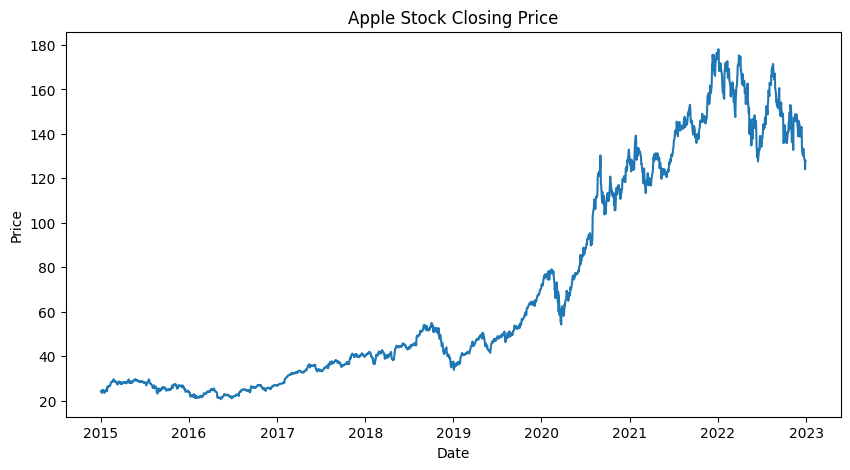

In [17]:
plt.figure(figsize=(10,5))

plt.plot(data['Close'])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [18]:
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]

test = data.iloc[train_size:]

print("Training samples:", len(train))

print("Testing samples:", len(test))

Training samples: 1611
Testing samples: 403


In [19]:
window = 5

history = list(train['Close'])

ma_forecast = []

for t in range(len(test)):

    yhat = np.mean(history[-window:])

    ma_forecast.append(yhat)

    history.append(test['Close'].iloc[t])

In [20]:
model_es = ExponentialSmoothing(train['Close'])

fit_es = model_es.fit()

es_forecast = fit_es.forecast(len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [21]:
model_arima = ARIMA(train['Close'], order=(5,1,0))

fit_arima = model_arima.fit()

arima_forecast = fit_arima.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

In [22]:
mae_ma = mean_absolute_error(test['Close'], ma_forecast)

mae_es = mean_absolute_error(test['Close'], es_forecast)

mae_arima = mean_absolute_error(test['Close'], arima_forecast)

rmse_ma = np.sqrt(mean_squared_error(test['Close'], ma_forecast))

rmse_es = np.sqrt(mean_squared_error(test['Close'], es_forecast))

rmse_arima = np.sqrt(mean_squared_error(test['Close'], arima_forecast))

In [23]:
print("Model Performance")

print("Moving Average MAE:", mae_ma)
print("Moving Average RMSE:", rmse_ma)

print("Exponential Smoothing MAE:", mae_es)
print("Exponential Smoothing RMSE:", rmse_es)

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

Model Performance
Moving Average MAE: 3.2600331498138955
Moving Average RMSE: 4.112807839459389
Exponential Smoothing MAE: 25.843032306142163
Exponential Smoothing RMSE: 28.917602862325108
ARIMA MAE: 25.855973581686953
ARIMA RMSE: 28.929714080896943


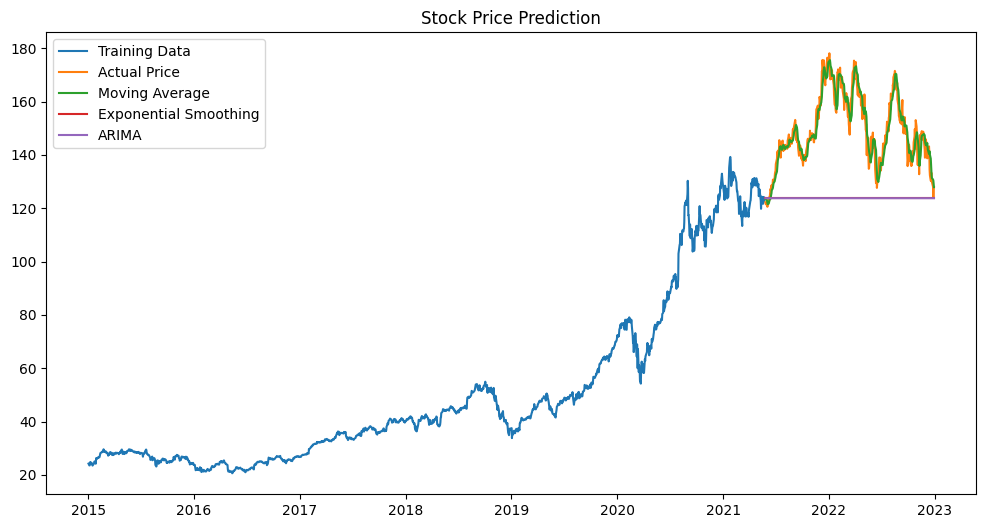

In [24]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Close'], label="Training Data")

plt.plot(test.index, test['Close'], label="Actual Price")

plt.plot(test.index, ma_forecast, label="Moving Average")

plt.plot(test.index, es_forecast, label="Exponential Smoothing")

plt.plot(test.index, arima_forecast, label="ARIMA")

plt.legend()

plt.title("Stock Price Prediction")

plt.show()